<a href="https://colab.research.google.com/github/Eritriharyanto/Sistem-Pakar-Untuk-Mendiagnosa-Penyakit-Pada-Daun-Padi/blob/main/my_padi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SISTEM PAKAR UNTUK MENDIAGNOSA PENYAKIT PADA DAUN PADI**

LINK DATASET: https://www.kaggle.com/competitions/paddy-disease-classification/data

## Alur Pengerjaan

1. **IMPORT** — import library, cek versi TensorFlow, set seed, mount Google Drive.
2. **EDA** — cek folder & jumlah kelas, lihat distribusi jumlah gambar per kelas, tampilkan contoh gambar tiap kelas.
3. **TRAIN AND VAL** — buat data generator (augmentasi untuk train, tanpa augmentasi untuk val) dan hitung class weight untuk mengatasi imbalance dataset.
4. **MODEL** — bangun model berbasis MobileNetV2 (transfer learning + fine-tuning sebagian layer), compile, dan siapkan callback (EarlyStopping & ModelCheckpoint).
5. **Training** — latih model tahap awal, lalu fine-tuning dengan learning rate lebih kecil.
6. **EVALUASI** — plot akurasi/loss, classification report, confusion matrix, lalu simpan model.
7. **PREDIKSI & REKOMENDASI (Modul Sistem Pakar)** — basis pengetahuan deskripsi & rekomendasi per penyakit, fungsi prediksi + diagnosis, serta Grad-CAM untuk visualisasi alasan diagnosis.
8. **SUBMISSION** — jalankan prediksi ke seluruh data test dan simpan hasil ke `submission.csv`.

# IMPORT

**Import Library**

In [ ]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
# Pastikan opencv tersedia (untuk augmentasi blur ringan di bagian bawah).
# Di Google Colab biasanya sudah terpasang, baris ini aman dijalankan berulang.
!pip install -q opencv-python-headless

In [ ]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# EDA

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/padi-saya"

TRAIN_DIR = os.path.join(DATASET_PATH, "train_images")
TEST_DIR = os.path.join(DATASET_PATH, "test_images")

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
print("Train folder:", CLASS_NAMES)
print("Jumlah kelas:", len(CLASS_NAMES))

Train folder: ['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']
Jumlah kelas: 10


**Distribusi Jumlah Gambar per Kelas**

                      kelas  jumlah_gambar
0  bacterial_panicle_blight            337
1     bacterial_leaf_streak            380
2     bacterial_leaf_blight            479
3              downy_mildew            620
4                brown_spot            965
5                    tungro           1089
6                dead_heart           1443
7                     hispa           1594
8                     blast           1740
9                    normal           1765


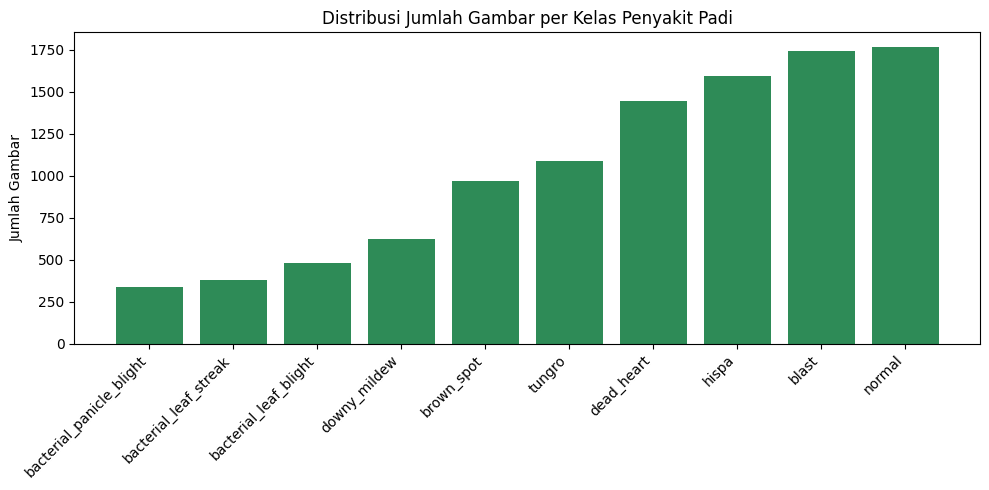

In [ ]:
class_counts = {
    cls: len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    for cls in CLASS_NAMES
}

count_df = pd.DataFrame(
    sorted(class_counts.items(), key=lambda x: x[1]),
    columns=["kelas", "jumlah_gambar"]
)
print(count_df)

plt.figure(figsize=(10, 5))
plt.bar(count_df["kelas"], count_df["jumlah_gambar"], color="seagreen")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Jumlah Gambar")
plt.title("Distribusi Jumlah Gambar per Kelas Penyakit Padi")
plt.tight_layout()
plt.show()

**Contoh Gambar per Kelas**

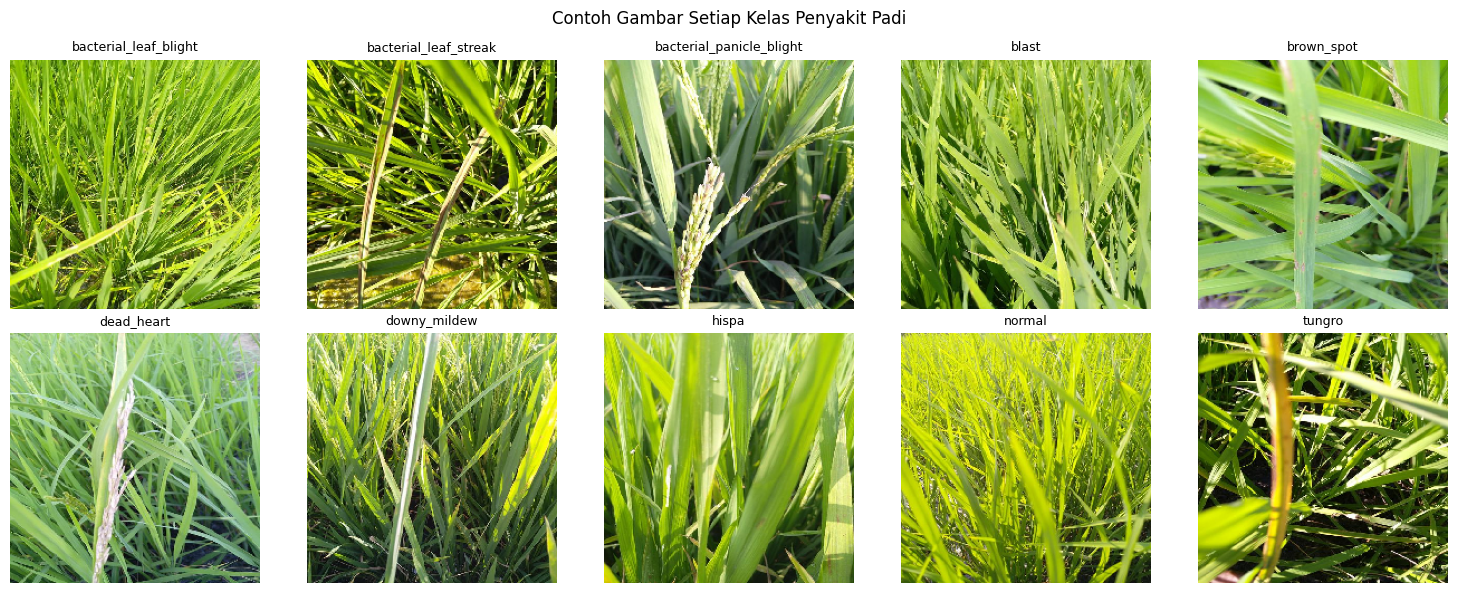

In [ ]:
plt.figure(figsize=(15, 6))
for i, cls in enumerate(CLASS_NAMES):
    folder = os.path.join(TRAIN_DIR, cls)
    img_name = os.listdir(folder)[0]
    img_path = os.path.join(folder, img_name)
    img = image.load_img(img_path, target_size=(224, 224))

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(cls, fontsize=9)
    plt.axis("off")

plt.suptitle("Contoh Gambar Setiap Kelas Penyakit Padi")
plt.tight_layout()
plt.show()

> **Revisi (v2):** Augmentasi data diperkuat (brightness, contrast, blur ringan, shift, shear, channel shift) dan generator validasi dipisah dari generator training (validasi tidak lagi ikut teraugmentasi). Tujuannya supaya model lebih tahan terhadap variasi kondisi foto dunia nyata (kamera HP, pencahayaan lapangan) yang berbeda dari kondisi foto dataset Kaggle. **Setelah ini, training (Cell 8 & fine-tuning) perlu dijalankan ulang dari awal.**

# TRAIN AND VAL

**Data Augmentation**

In [ ]:
# augmentasi lebih agresif + generator terpisah untuk train & val
#
# Kenapa direvisi:
# - Sebelumnya train & val pakai satu ImageDataGenerator yang sama, jadi
#   augmentasi ikut diterapkan ke data validasi (idealnya validasi harus
#   merepresentasikan data "asli" tanpa augmentasi acak).
# - Augmentasi diperkuat (brightness, contrast, blur ringan, shift, shear,
#   channel shift) supaya model terbiasa dengan variasi kondisi foto
#   dunia nyata (pencahayaan HP, kamera berbeda, sedikit blur, dll),
#   bukan cuma foto dataset yang kondisinya seragam.

IMG_SIZE = (224, 224)
BATCH_SIZE = 32


def augmented_preprocess(img):
    """Simulasikan variasi kondisi kamera dunia nyata sebelum preprocess_input.
    Dipanggil oleh ImageDataGenerator, menerima & mengembalikan array HWC float32."""
    # Blur ringan acak (tiru foto sedikit tidak fokus / kompresi HP)
    if random.random() < 0.3:
        ksize = random.choice([3, 5])
        img = cv2.GaussianBlur(img, (ksize, ksize), 0)

    # Jitter kontras acak
    if random.random() < 0.5:
        alpha = random.uniform(0.8, 1.25)
        img = np.clip(img * alpha, 0, 255)

    return preprocess_input(img)


# Generator untuk TRAIN: augmentasi agresif
train_datagen = ImageDataGenerator(
    preprocessing_function=augmented_preprocess,
    validation_split=0.2,
    rotation_range=30,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    shear_range=0.15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    brightness_range=[0.6, 1.4],
    channel_shift_range=30.0,
    fill_mode="nearest",
)

# Generator untuk VALIDASI: TANPA augmentasi acak, hanya preprocess_input,
# supaya angka evaluasi tetap mencerminkan performa asli model.
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_generator = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

NUM_CLASSES = len(train_generator.class_indices)
print("Jumlah kelas:", NUM_CLASSES)
print(train_generator.class_indices)

# Catatan: train_generator dan val_generator memakai validation_split yang
# sama (0.2) dan seed yang sama, sehingga split data tetap konsisten
# walau menggunakan dua obyek ImageDataGenerator yang berbeda.


Found 8333 images belonging to 10 classes.
Found 2079 images belonging to 10 classes.
Jumlah kelas: 10
{'bacterial_leaf_blight': 0, 'bacterial_leaf_streak': 1, 'bacterial_panicle_blight': 2, 'blast': 3, 'brown_spot': 4, 'dead_heart': 5, 'downy_mildew': 6, 'hispa': 7, 'normal': 8, 'tungro': 9}


In [ ]:
print(train_generator.class_indices)

{'bacterial_leaf_blight': 0, 'bacterial_leaf_streak': 1, 'bacterial_panicle_blight': 2, 'blast': 3, 'brown_spot': 4, 'dead_heart': 5, 'downy_mildew': 6, 'hispa': 7, 'normal': 8, 'tungro': 9}


**Class Weight (mengatasi imbalance dataset)**

In [ ]:
# Cell 4.1
classes = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(2.170052083333333), 1: np.float64(2.7411184210526316), 2: np.float64(3.0862962962962963), 3: np.float64(0.5986350574712643), 4: np.float64(1.0794041450777203), 5: np.float64(0.7214718614718615), 6: np.float64(1.680040322580645), 7: np.float64(0.6530564263322884), 8: np.float64(0.590155807365439), 9: np.float64(0.9556192660550459)}


# MODEL

**Build**

In [ ]:
# Cell 5
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze sebagian saja, buka 30 layer terakhir agar bisa fine-tuning
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 1,691,658 (6.45 MB)

 Non-trainable params: 731,584 (2.79 MB)

**Compile**

In [ ]:
# Cell 6
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**EarlyStopping / Callbacks**

In [ ]:
# Cell 7
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "model_padi_best.keras",
    monitor='val_accuracy',
    save_best_only=True
)

**Train**

In [ ]:
# Cell 8
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 3577s 14s/step - accuracy: 0.2396 - loss: 2.0931 - val_accuracy: 0.1347 - val_loss: 2.7681
Epoch 2/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 228s 874ms/step - accuracy: 0.4128 - loss: 1.6329 - val_accuracy: 0.3444 - val_loss: 1.9321
Epoch 3/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 232s 890ms/step - accuracy: 0.5082 - loss: 1.3912 - val_accuracy: 0.4425 - val_loss: 1.7374
Epoch 4/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 234s 896ms/step - accuracy: 0.5662 - loss: 1.2015 - val_accuracy: 0.5969 - val_loss: 1.2320
Epoch 5/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 218s 835ms/step - accuracy: 0.6061 - loss: 1.0960 - val_accuracy: 0.6022 - val_loss: 1.3484
Epoch 6/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 195s 748ms/step - accuracy: 0.6435 - loss: 1.0117 - val_accuracy: 0.5878 - val_loss: 1.4201
Epoch 7/25
 76/261 ━━━━━━━━━━━━━━━━━━━━ 2:05 681ms/step - accuracy: 0.6782 - loss: 0.9038

In [ ]:
# ==========================
# Fine Tuning MobileNetV2
# ==========================

# Buka 30 layer terakhir MobileNetV2 (sudah dilakukan saat build, dipertahankan di sini agar eksplisit)
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

# Compile ulang dengan learning rate kecil
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Training Fine Tuning
# class_weight tetap disertakan agar penanganan imbalance konsisten
fine_tune_epochs = 10

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=fine_tune_epochs,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint]
)

In [ ]:
# Simpan riwayat training supaya bisa dianalisis ulang tanpa training lagi
full_history = {
    "accuracy": history.history['accuracy'] + history_fine.history['accuracy'],
    "val_accuracy": history.history['val_accuracy'] + history_fine.history['val_accuracy'],
    "loss": history.history['loss'] + history_fine.history['loss'],
    "val_loss": history.history['val_loss'] + history_fine.history['val_loss'],
}

with open("training_history.json", "w") as f:
    json.dump(full_history, f)

print("Riwayat training disimpan ke training_history.json")

# EVALUASI

**Akurasi & Loss**

In [ ]:
# Cell 9
acc = full_history["accuracy"]
val_acc = full_history["val_accuracy"]
loss = full_history["loss"]
val_loss = full_history["val_loss"]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(acc, label="Train")
plt.plot(val_acc, label="Validation")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label="Train")
plt.plot(val_loss, label="Validation")
plt.title("Loss")
plt.legend()

plt.show()

**Confusion Matrix & Classification Report (Validation Set)**\n\nBagian ini wajib ada untuk dataset yang imbalance: accuracy keseluruhan bisa tinggi walau kelas minoritas (mis. `bacterial_panicle_blight`) justru sering salah diprediksi.

In [ ]:
# Evaluasi menyeluruh di val_generator
val_generator.reset()
val_steps = int(np.ceil(val_generator.samples / val_generator.batch_size))

y_pred_probs = model.predict(val_generator, steps=val_steps)
y_pred = np.argmax(y_pred_probs, axis=1)[:val_generator.samples]
y_true = val_generator.classes

labels_list = list(val_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=labels_list))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_list)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Validation Set")
plt.tight_layout()
plt.show()

**Simpan Model**

In [ ]:
# Cell 10
model.save("/content/model_padi_final.keras")
print("Model saved!")

# PREDIKSI & REKOMENDASI (Modul Sistem Pakar)

Bagian ini melengkapi model CNN dengan lapisan "basis pengetahuan" sederhana: hasil klasifikasi citra dipetakan ke deskripsi penyakit dan rekomendasi penanganan, sehingga keluaran sistem tidak hanya berupa label, tapi juga penjelasan yang bisa digunakan petani/pengguna (ciri khas sistem pakar).

In [ ]:
# Basis pengetahuan sederhana: deskripsi & rekomendasi per kelas
DISEASE_INFO = {
    "bacterial_leaf_blight": {
        "deskripsi": "Penyakit hawar daun bakteri yang menyebabkan daun menguning dan mengering dari ujung.",
        "rekomendasi": "Gunakan benih sehat, perbaiki drainase, dan aplikasikan bakterisida berbahan tembaga bila perlu."
    },
    "bacterial_leaf_streak": {
        "deskripsi": "Penyakit garis daun bakteri, muncul garis-garis basah pada daun yang lama-lama menyatu.",
        "rekomendasi": "Kurangi kelembapan berlebih, gunakan varietas tahan, dan sanitasi sisa tanaman terinfeksi."
    },
    "bacterial_panicle_blight": {
        "deskripsi": "Penyakit hawar malai bakteri, menyebabkan malai kosong/hampa terutama pada suhu tinggi.",
        "rekomendasi": "Atur waktu tanam untuk menghindari suhu ekstrem saat pembungaan dan jaga jarak tanam."
    },
    "blast": {
        "deskripsi": "Penyakit blas (disebabkan jamur Magnaporthe oryzae), muncul bercak berbentuk belah ketupat pada daun.",
        "rekomendasi": "Gunakan fungisida yang sesuai, hindari pemupukan nitrogen berlebih, dan gunakan varietas tahan blas."
    },
    "brown_spot": {
        "deskripsi": "Bercak coklat pada daun akibat jamur, sering terjadi pada tanaman kekurangan hara.",
        "rekomendasi": "Perbaiki kesuburan tanah (terutama kalium), aplikasikan fungisida bila serangan berat."
    },
    "dead_heart": {
        "deskripsi": "Gejala pucuk mati akibat serangan hama penggerek batang.",
        "rekomendasi": "Gunakan perangkap hama, insektisida sistemik, dan pantau populasi ngengat penggerek batang."
    },
    "downy_mildew": {
        "deskripsi": "Penyakit embun bulu, muncul lapisan seperti kapas keabuan di permukaan daun.",
        "rekomendasi": "Perbaiki sirkulasi udara, kurangi kelembapan, dan gunakan fungisida spesifik bila diperlukan."
    },
    "hispa": {
        "deskripsi": "Kerusakan akibat hama kumbang hispa yang mengorek jaringan daun.",
        "rekomendasi": "Gunakan insektisida kontak, sanitasi gulma inang, dan pantau populasi hama secara berkala."
    },
    "normal": {
        "deskripsi": "Tanaman dalam kondisi sehat, tidak menunjukkan gejala penyakit.",
        "rekomendasi": "Lanjutkan perawatan rutin dan pemantauan berkala."
    },
    "tungro": {
        "deskripsi": "Penyakit tungro yang disebabkan virus dan ditularkan oleh wereng hijau.",
        "rekomendasi": "Kendalikan populasi wereng hijau sebagai vektor, cabut tanaman terinfeksi, gunakan varietas tahan tungro."
    },
}

def get_disease_info(label):
    return DISEASE_INFO.get(label, {"deskripsi": "Tidak ada data.", "rekomendasi": "Tidak ada data."})

In [ ]:
# Fungsi prediksi tunggal (mengembalikan label + confidence)
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    pred = model.predict(img_array, verbose=0)[0]
    class_idx = np.argmax(pred)

    labels = list(train_generator.class_indices.keys())
    label = labels[class_idx]
    confidence = float(pred[class_idx])
    return label, confidence

def diagnose(img_path):
    label, confidence = predict_image(img_path)
    info = get_disease_info(label)
    print(f"Gambar       : {img_path}")
    print(f"Diagnosis    : {label} (confidence: {confidence:.2%})")
    print(f"Deskripsi    : {info['deskripsi']}")
    print(f"Rekomendasi  : {info['rekomendasi']}")
    return label, confidence

# contoh
test_img = os.path.join(TEST_DIR, os.listdir(TEST_DIR)[0])
_ = diagnose(test_img)

In [ ]:
# Contoh diagnosis untuk beberapa gambar test
for i in range(5):
    test_img = os.path.join(TEST_DIR, os.listdir(TEST_DIR)[i])
    diagnose(test_img)
    print("-" * 60)

**Grad-CAM (Visualisasi Alasan Diagnosis)**\n\nMenunjukkan bagian citra yang paling memengaruhi keputusan model — penting agar sistem bisa 'menjelaskan' diagnosisnya, bukan sekadar memberi label.

In [ ]:
# Grad-CAM sederhana untuk MobileNetV2
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="Conv_1"):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
        if hasattr(model, "get_layer") and last_conv_layer_name in [l.name for l in model.layers]
        else [model.layers[0].get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def show_gradcam(img_path, last_conv_layer_name="Conv_1"):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array_exp = np.expand_dims(img_array, axis=0)
    img_array_pre = preprocess_input(img_array_exp.copy())

    heatmap = make_gradcam_heatmap(img_array_pre, model, last_conv_layer_name)
    heatmap_resized = tf.image.resize(heatmap[..., tf.newaxis], (224, 224)).numpy().squeeze()

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img_array.astype("uint8"))
    plt.title("Gambar Asli")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img_array.astype("uint8"))
    plt.imshow(heatmap_resized, cmap="jet", alpha=0.5)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# contoh (sesuaikan nama layer konvolusi terakhir MobileNetV2 jika berbeda: "Conv_1")
test_img = os.path.join(TEST_DIR, os.listdir(TEST_DIR)[0])
try:
    show_gradcam(test_img)
except Exception as e:
    print("Grad-CAM gagal dijalankan, cek nama layer konvolusi terakhir di model.summary():", e)

# SUBMISSION

In [ ]:
# Cell 12 - Submission (bug diperbaiki: predict_image mengembalikan tuple,
# sehingga label dan confidence dipisah ke kolom masing-masing)
test_files = os.listdir(TEST_DIR)
results = []

for file in test_files:
    path = os.path.join(TEST_DIR, file)
    pred_label, confidence = predict_image(path)
    results.append([file, pred_label, confidence])

df = pd.DataFrame(results, columns=['image_id', 'label', 'confidence'])

# Format submission Kaggle biasanya hanya butuh image_id & label
df[['image_id', 'label']].to_csv("submission.csv", index=False)
# Simpan juga versi lengkap dengan confidence untuk keperluan analisis internal
df.to_csv("submission_with_confidence.csv", index=False)

print("Submission saved!")
df.head()

In [ ]:
# Simpan mapping label kelas
with open("labels.json", "w") as f:
    json.dump(train_generator.class_indices, f)

print("labels.json saved!")